In [1]:
"""
plot_profit_no_transparency.ipynb

Random-split heuristic: per-model curves of the number of "overcharged"
tokens vs the number of split iterations m, plotted without confidence
bands. Pickle inputs are read from ``outputs/cpt/`` and the figure is
saved under ``figures/heur/``.

The notebook proceeds in two stages:

1. Compute ``profit_increase`` for each model and save it as a small
   pickle (cell with ``split_m`` / ``get_profit_increase``). This is
   expensive: run it once per model.
2. Load all five per-model pickles and plot the curves together.
"""

%matplotlib inline

import os
import sys
import pickle
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer

# Resolve project paths from the notebook's location: <work>/notebooks/...
WORK_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
CPT_DIR = os.path.join(WORK_DIR, "outputs", "cpt")
FIGURES_DIR = os.path.join(WORK_DIR, "figures")

sys.path.insert(0, os.path.join(WORK_DIR, "src"))
import utils  # noqa: E402

# Short name -> (filename stem used in outputs/cpt/, HuggingFace model id).
MODEL_INFO = {
    "L1B": ("Llama-3.2-1B-Instruct",        "meta-llama/Llama-3.2-1B-Instruct"),
    "L3B": ("Llama-3.2-3B-Instruct",        "meta-llama/Llama-3.2-3B-Instruct"),
    "G1B": ("Gemma-3-1b-it",                "google/gemma-3-1b-it"),
    "G4B": ("Gemma-3-4b-it",                "google/gemma-3-4b-it"),
    "M8B": ("Ministral-8B-Instruct-2410",   "mistralai/Ministral-8B-Instruct-2410"),
}


In [ ]:
# Load the English factual_model outputs (T=1.0, top-p=1.0) and the
# matching tokenizer for each of the five models. Variable names match
# the original notebook so the cells below can stay unchanged.

TOKENIZERS = {
    short: AutoTokenizer.from_pretrained(hf) for short, (_, hf) in MODEL_INFO.items()
}
tokenizer_L1B = TOKENIZERS["L1B"]
tokenizer_L3B = TOKENIZERS["L3B"]
tokenizer_G1B = TOKENIZERS["G1B"]
tokenizer_G4B = TOKENIZERS["G4B"]
tokenizer_M8B = TOKENIZERS["M8B"]


def load_factual(short_name, top_p=1.0, temperature=1.0, num_prompts=400):
    """Load ``factual_model<MS>_p<P>_kNone_numprompts<NP>_maxoutlen200_temp<T>.pkl``
    from ``CPT_DIR``."""
    model_str = MODEL_INFO[short_name][0]
    fname = (f"factual_model{model_str}_p{top_p}_kNone_"
             f"numprompts{num_prompts}_maxoutlen200_temp{temperature}.pkl")
    with open(os.path.join(CPT_DIR, fname), "rb") as f:
        return pickle.load(f)


data_L1B_p1_T1 = load_factual("L1B")
data_L3B_p1_T1 = load_factual("L3B")
data_G1B_p1_T1 = load_factual("G1B")
data_G4B_p1_T1 = load_factual("G4B")
data_M8B_p1_T1 = load_factual("M8B")


In [ ]:
def split_m_naive(output, m, tokenizer):
    """First (slow) version of the random-split heuristic.

    For each of ``m`` iterations: pick a random multi-character token in
    ``output``, find a prefix/suffix split whose halves are both in the
    vocabulary, and replace the token by the two halves. Recomputes the
    reverse vocabulary ``str -> id`` on every call, so it is O(|V|) per
    call. See ``split_m`` below for the optimized version.
    """
    # token id -> decoded string (only for ids actually in `output`)
    id_to_str = {tid: tokenizer.decode([tid]) for tid in set(output)}
    # Reverse vocabulary: string -> token id.
    str_to_id = {}
    for tid in tokenizer.get_vocab().values():
        s = tokenizer.decode([tid])
        str_to_id[s] = tid

    for _ in range(m):
        multi_indices = [i for i, tid in enumerate(output) if len(id_to_str[tid]) > 1]
        if not multi_indices:
            return output  # Nothing to split

        idx = random.choice(multi_indices)
        token_id = output[idx]
        token_str = id_to_str[token_id]

        split_found = False
        for j in range(1, len(token_str)):
            prefix, suffix = token_str[:j], token_str[j:]
            if prefix in str_to_id and suffix in str_to_id:
                prefix_id = str_to_id[prefix]
                suffix_id = str_to_id[suffix]
                output = output[:idx] + [prefix_id, suffix_id] + output[idx + 1:]
                if prefix_id not in id_to_str:
                    id_to_str[prefix_id] = prefix
                if suffix_id not in id_to_str:
                    id_to_str[suffix_id] = suffix
                split_found = True
                break

        if not split_found:
            continue

    return output


def get_profit_increase_naive(data, m, tokenizer):
    """Naive companion to ``split_m_naive``: rebuilds the vocab maps on
    every call."""
    total_tok = 0
    total_tok_after = 0

    for prompt_idx in range(300):
        output = [i.item() for i in data[prompt_idx]["output"][0]]
        print("Prompt", prompt_idx)
        num_tok = len(output)
        output_after = split_m_naive(output, m, tokenizer)
        num_tok_after = len(output_after)
        total_tok += num_tok
        total_tok_after += num_tok_after
    return 100 * (total_tok_after / total_tok - 1)


In [34]:
# Optimized split-m and profit-change computation. ``build_token_maps``
# precomputes the (id <-> str) mappings once per tokenizer, instead of
# rebuilding them inside ``split_m`` for every call.
#
# This cell saves the result for one model only; to regenerate the
# pickles consumed by the plotting cell below, run this cell once per
# entry of ``MODEL_INFO`` (changing ``short`` accordingly).


def build_token_maps(tokenizer):
    """Precompute ``id_to_str`` and ``str_to_id`` for the tokenizer's
    vocabulary (collisions on the string side keep the first id)."""
    vocab = tokenizer.get_vocab()
    id_to_str = {}
    str_to_id = {}
    for tok, tid in vocab.items():
        s = tokenizer.decode([tid])
        if s not in str_to_id:
            str_to_id[s] = tid
        id_to_str[tid] = s
    return id_to_str, str_to_id


def split_m(output, m, id_to_str, str_to_id):
    """Iteratively split tokens in ``output`` into a valid (prefix,
    suffix) pair, for up to ``m`` iterations. Mutates ``output``."""
    for _ in range(m):
        multi_indices = [i for i, tid in enumerate(output) if len(id_to_str[tid]) > 1]
        if not multi_indices:
            break

        idx = random.choice(multi_indices)
        token_id = output[idx]
        token_str = id_to_str[token_id]

        for j in range(1, len(token_str)):
            prefix, suffix = token_str[:j], token_str[j:]
            if prefix in str_to_id and suffix in str_to_id:
                output[idx:idx + 1] = [str_to_id[prefix], str_to_id[suffix]]
                break
    return output


def get_profit_increase(data, m, tokenizer, max_prompts=300):
    """Percentage change in total token count after applying ``split_m``
    with ``m`` iterations to each of the first ``max_prompts`` prompts."""
    id_to_str, str_to_id = build_token_maps(tokenizer)

    total_tok = 0
    total_tok_after = 0
    for prompt_idx, prompt in enumerate(data[:max_prompts]):
        output = [i.item() for i in prompt["output"][0]]
        num_tok = len(output)
        output_after = split_m(output, m, id_to_str, str_to_id)
        num_tok_after = len(output_after)
        total_tok += num_tok
        total_tok_after += num_tok_after
    return 100 * (total_tok_after / total_tok - 1)


# Example: run for Ministral-8B and save the result. Change ``short`` to
# regenerate the pickle for a different model.
range_m = [0, 300, 600, 800, 900, 1000, 1100, 1200, 1300]
short = "M8B"
data = data_M8B_p1_T1
tokenizer = TOKENIZERS[short]

profit_increase = [get_profit_increase(data, m, tokenizer) for m in range_m]

out_path = os.path.join(CPT_DIR, f"random_proft_change_{short}.pkl")
with open(out_path, "wb") as f:
    pickle.dump(profit_increase, f)


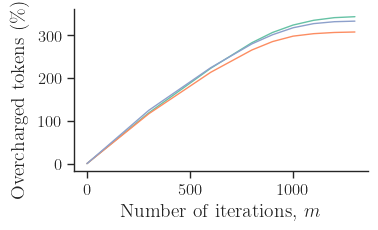

In [10]:
# Load each model's profit-change pickle and plot the three curves
# (L1B, G1B, M8B) on a common axis. L3B and G4B are intentionally
# excluded from the plot (their sns.lineplot calls were commented out in
# the source notebook), but their pickles are loaded as a sanity check
# that they exist.

range_m = [0, 300, 600, 800, 900, 1000, 1100, 1200, 1300]

sns.set_theme(context="paper", style="ticks", font_scale=1)
palette = sns.color_palette("Set2")
utils.latexify()  # Computer Modern, with TeX

fig_width, fig_height = utils.get_fig_dim(469, fraction=0.6)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

profit_increase = {}
for short in ["L1B", "L3B", "G1B", "G4B", "M8B"]:
    path = os.path.join(CPT_DIR, f"random_proft_change_{short}.pkl")
    with open(path, "rb") as f:
        profit_increase[short] = pickle.load(f)

sns.lineplot(x=range_m, y=profit_increase["L1B"], color=palette[0], ax=ax,
             linewidth=1, markersize=4, linestyle="-", markeredgewidth=0)
sns.lineplot(x=range_m, y=profit_increase["G1B"], color=palette[1], ax=ax,
             linewidth=1, markersize=4, linestyle="-", markeredgewidth=0)
sns.lineplot(x=range_m, y=profit_increase["M8B"], color=palette[2], ax=ax,
             linewidth=1, markersize=4, linestyle="-", markeredgewidth=0)

ax.set_ylabel(r"Overcharged tokens $(\%)$", fontsize=14)
ax.yaxis.set_label_coords(-0.15, 0.45)
ax.set_xlabel(r"Number of iterations, $m$", fontsize=14)
sns.despine(ax=ax)
ax.tick_params(axis="y", which="major", labelsize=12)
ax.tick_params(axis="x", which="major", labelsize=12)

fig.tight_layout()
plt.show()
out_path = os.path.join(FIGURES_DIR, "heur", "random_profit_increase_no_transparency.pdf")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
fig.savefig(out_path, dpi=300)
